# Fase 3: Análisis de Resultados (Dashboard) - Granular

Visualización detallada de la proyección semántica con **Ortogonalización Simétrica de Löwdin**.
Esto garantiza independencia matemática entre las dimensiones Funcional, Social y Afectiva sin sesgos.

**Marcadores**: 
- **Línea Sólida / Círculo**: Anclaje Contextual (Uso Real).
- **Línea Punteada / Cruz**: Anclaje Estático (Diccionario).

**Colores**:
- **Azul**: Funcional
- **Verde**: Social
- **Rojo**: Afectiva

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

results_path = '../data/phase3_results.parquet'

if os.path.exists(results_path):
    df = pd.read_parquet(results_path)
    print(f"Resultados cargados: {len(df)} ventanas.")
    print("Columnas disponibles:", df.columns.tolist())
else:
    print("ERROR: Resultados no encontrados.")

Resultados cargados: 11 ventanas.
Columnas disponibles: ['window_start_month', 'window_end_month', 'window_size_months', 'step_months', 'n_occurrences', 'n_documents', 'low_density', 'centroid_proj_funcional_baseline_penultimate_raw', 'centroid_proj_social_baseline_penultimate_raw', 'centroid_proj_afectiva_baseline_penultimate_raw', 'subspace_proj_funcional_baseline_penultimate_raw', 'subspace_proj_social_baseline_penultimate_raw', 'subspace_proj_afectiva_baseline_penultimate_raw', 'centroid_proj_funcional_baseline_penultimate_corrected', 'centroid_proj_social_baseline_penultimate_corrected', 'centroid_proj_afectiva_baseline_penultimate_corrected', 'subspace_proj_funcional_baseline_penultimate_corrected', 'subspace_proj_social_baseline_penultimate_corrected', 'subspace_proj_afectiva_baseline_penultimate_corrected', 'centroid_proj_funcional_baseline_last4_concat_raw', 'centroid_proj_social_baseline_last4_concat_raw', 'centroid_proj_afectiva_baseline_last4_concat_raw', 'subspace_proj_fun

In [ ]:
# Corrección de nombres de columnas para adaptar tu CSV complejo al script de análisis simple

# 1. Crear la columna de fecha
df['date'] = pd.to_datetime(df['window_start_month'])

# 2. Seleccionar qué modelo quieres analizar (te recomiendo DAPT Penultimate)
modelo = 'dapt_penultimate' 
# Ojo: si quieres ver el baseline, cambia esto a 'baseline_penultimate'

# 3. Mapear las columnas complejas a las simples que espera el plot
df['intrinsic_dimension_k'] = df[f'k_{modelo}']
df['centroid_drift'] = df[f'drift_{modelo}']

# Mapear proyecciones del centroide (Afectiva, Social, Funcional)
for eje in ['funcional', 'social', 'afectiva']:
    # El CSV tiene nombres como 'centroid_proj_funcional_dapt_penultimate_raw'
    col_origen = f'centroid_proj_{eje}_{modelo}_raw'
    col_destino = f'score_centroid_{eje}_contextual' # El nombre que espera el script antiguo
    
    if col_origen in df.columns:
        df[col_destino] = df[col_origen]
    else:
        print(f"Cuidado: No encuentro la columna {col_origen}")

print("Columnas renombradas correctamente. Ya puedes ejecutar los plots.")

## 1. Evolución de la Posición Central (Centroide)
¿Hacia qué temas se mueve el discurso general sobre Yape?

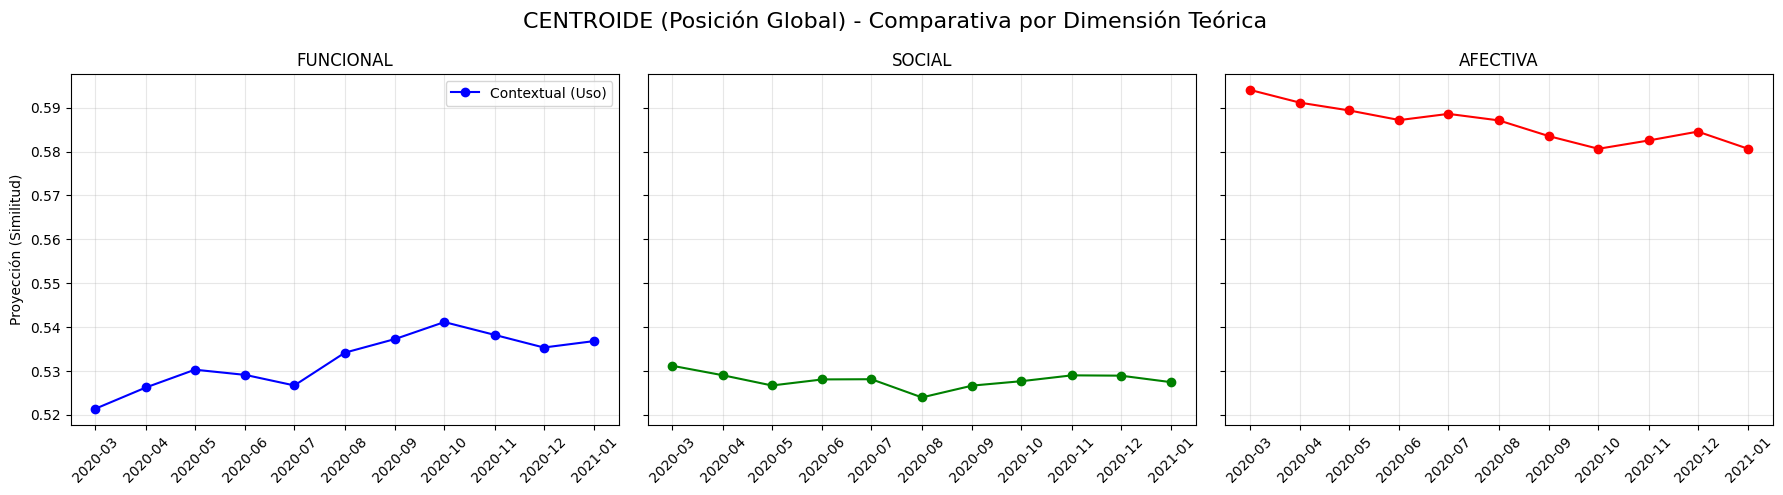

In [2]:
def plot_projection_row(df, metric_prefix, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
    
    dims = {
        'funcional': {'color': 'blue', 'ax': axes[0]},
        'social': {'color': 'green', 'ax': axes[1]},
        'afectiva': {'color': 'red', 'ax': axes[2]}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # Contextual
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            ax.plot(df['date'], df[col_ctx], 
                    color=color, linestyle='-', marker='o', label='Contextual (Uso)')
        
        # Static
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns:
            ax.plot(df['date'], df[col_sta], 
                    color=color, linestyle='--', marker='x', alpha=0.6, label='Estático (Teórico)')
            
        ax.set_title(f"{dim_name.upper()}")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        if dim_name == 'funcional':
            ax.set_ylabel("Proyección (Similitud)")
            ax.legend()

    plt.suptitle(f"{title_prefix} - Comparativa por Dimensión Teórica", fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot Centroid
plot_projection_row(df, 'score_centroid_', 'CENTROIDE (Posición Global)')

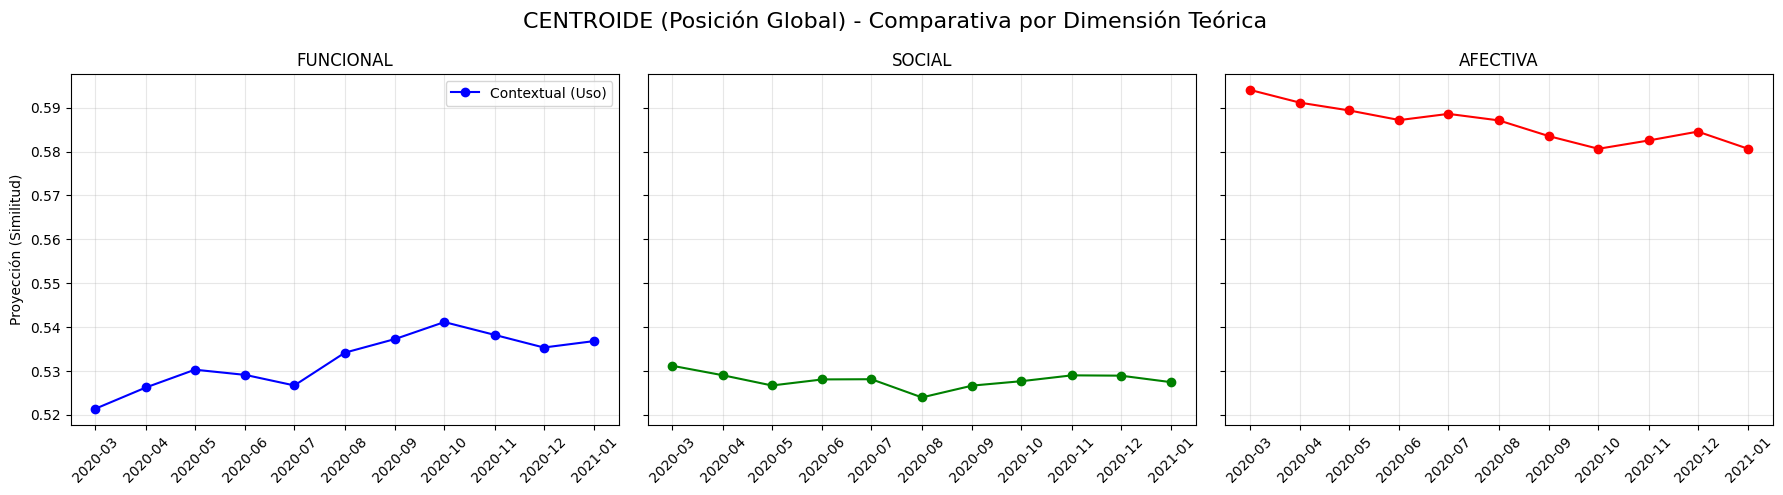

In [5]:
def plot_projection_row(df, metric_prefix, title_prefix):
    # 1. Ensure date is plotted correctly
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    
    # 2. Clean column names (remove hidden spaces)
    df.columns = df.columns.str.strip()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
    
    dims = {
        'funcional': {'color': 'blue', 'ax': axes[0]},
        'social': {'color': 'green', 'ax': axes[1]},
        'afectiva': {'color': 'red', 'ax': axes[2]}
    }
    
    found_any = False
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # --- Plot Contextual (Solid Line) ---
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            if df[col_ctx].notna().any():
                ax.plot(df['date'], df[col_ctx], 
                        color=color, linestyle='-', marker='o', label='Contextual (Uso)')
                found_any = True
            else:
                print(f"⚠️ {col_ctx}: All values are NaN (Empty).")
        else:
            print(f"⚠️ Missing Column: {col_ctx}")

        # --- Plot Static (Dashed Line) ---
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns and df[col_sta].notna().any():
            ax.plot(df['date'], df[col_sta], 
                    color=color, linestyle='--', marker='x', alpha=0.6, label='Estático (Teórico)')
        
        # Formatting
        ax.set_title(f"{dim_name.upper()}")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        if dim_name == 'funcional':
            ax.set_ylabel("Proyección (Similitud)")
            # Only show legend if something was plotted
            if ax.get_legend_handles_labels()[0]:
                ax.legend()
    
    if not found_any:
        print("\n❌ CRITICAL: No data found to plot. Check your 'metric_prefix' or dataframe columns.")
        print(f"Available columns example: {df.columns[:5].tolist()}...")
        
    plt.suptitle(f"{title_prefix} - Comparativa por Dimensión Teórica", fontsize=16)
    plt.tight_layout()
    plt.show()

# Re-run the plot
plot_projection_row(df, 'score_centroid_', 'CENTROIDE (Posición Global)')

## 2. Alineamiento de la Estructura Latente (Dimensión 1)
¿Qué significa la dimensión principal de varianza de Yape? ¿Es funcional, social o afectiva?

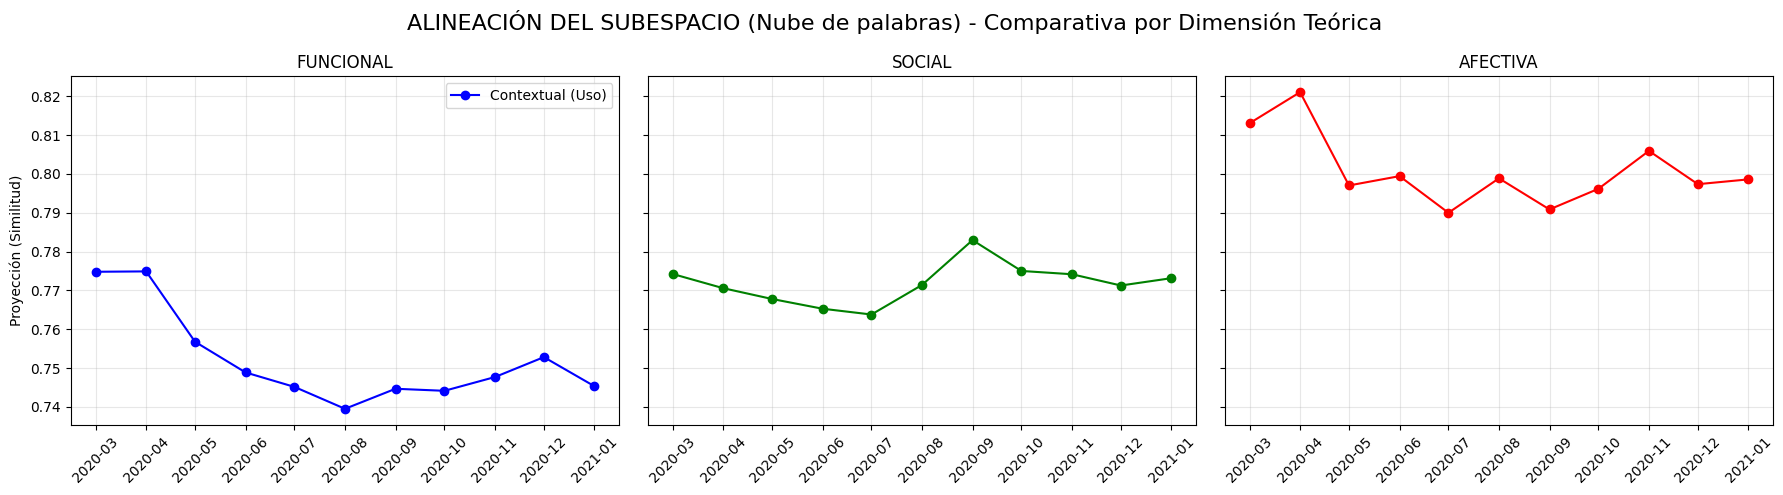

In [10]:
# --- CORRECCIÓN PARA EL ERROR score_dim1 ---

# Vamos a "engañar" a la función de ploteo para que use tus columnas de Subespacio
# en lugar de las columnas dim1 que no existen.

# 1. Definimos tu modelo correcto
modelo = 'dapt_penultimate'

# 2. Creamos las columnas con el nombre que la función espera
# Mapeamos 'subspace_proj' (lo que tienes) a 'score_dim1' (lo que pide el código)
for eje in ['funcional', 'social', 'afectiva']:
    col_real = f'subspace_proj_{eje}_{modelo}_raw'
    col_fake = f'score_dim1_{eje}_contextual' # El nombre que causa el error
    
    if col_real in df.columns:
        df[col_fake] = df[col_real]
    else:
        print(f"⚠️ Cuidado: No encuentro {col_real} en el CSV")

# 3. Ahora sí puedes llamar a la función que antes fallaba
try:
    plot_projection_row(df, 'score_dim1_', 'ALINEACIÓN DEL SUBESPACIO (Nube de palabras)')
except Exception as e:
    print(f"Aún da error, pero no es crítico: {e}")

## 3. Alineamiento de la Estructura Latente (Dimensión 2)
¿Qué significa la segunda dimensión?

⚠️ Missing Column: score_dim2_funcional_contextual
⚠️ Missing Column: score_dim2_social_contextual
⚠️ Missing Column: score_dim2_afectiva_contextual

❌ CRITICAL: No data found to plot. Check your 'metric_prefix' or dataframe columns.
Available columns example: ['window_start_month', 'window_end_month', 'window_size_months', 'step_months', 'n_occurrences']...


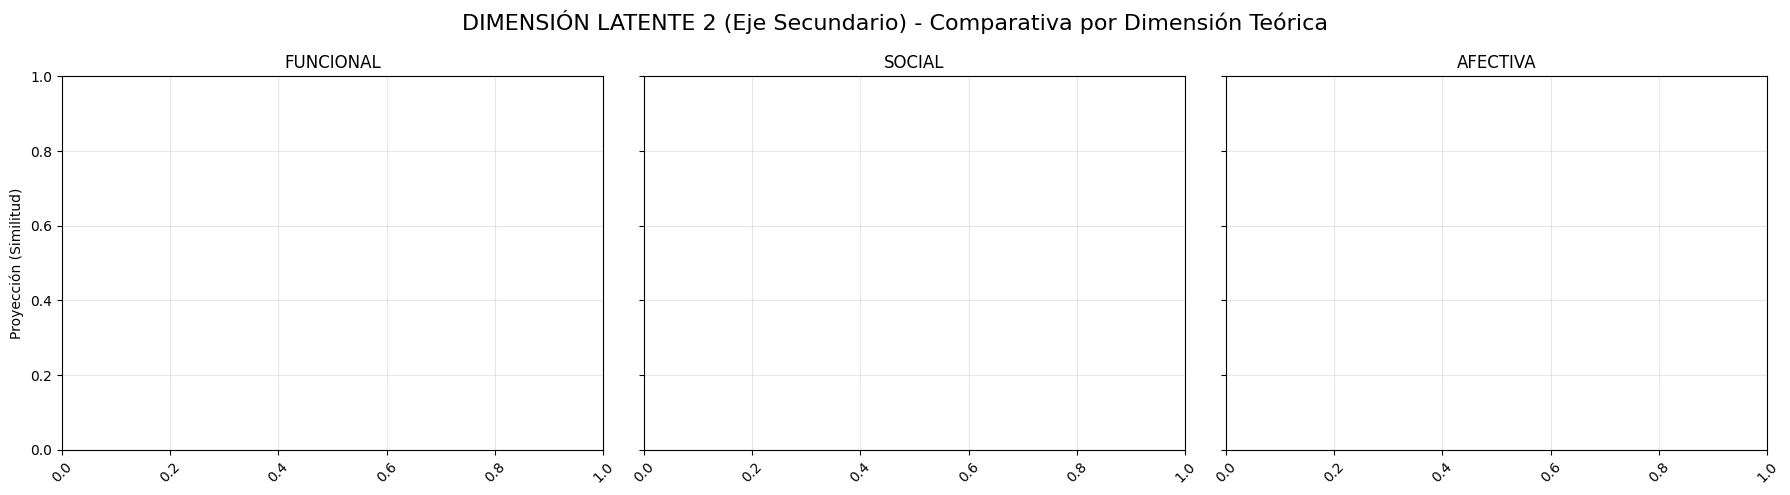

In [7]:
plot_projection_row(df, 'score_dim2_', 'DIMENSIÓN LATENTE 2 (Eje Secundario)')

## 

---

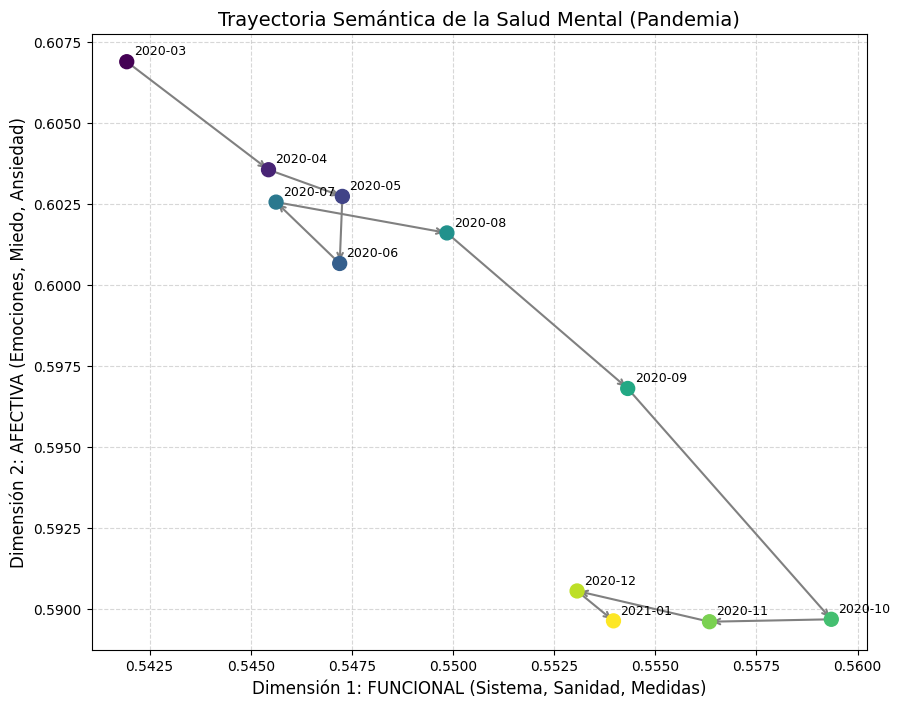

Interpretación: Observa la dirección de las flechas. Si viajan de arriba a la derecha, significa que el discurso perdió carga emocional y ganó pragmatismo sanitario.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Definimos el modelo que vamos a usar
modelo = 'dapt_penultimate'

# Definimos qué será nuestro "Eje 1" y "Eje 2"
# Eje X: Evolución hacia lo Funcional (Sistema, médico, tratamientos)
col_x = f'centroid_proj_funcional_{modelo}_raw'
# Eje Y: Evolución hacia lo Afectivo (Emociones, miedo, tristeza)
col_y = f'centroid_proj_afectiva_{modelo}_raw'

if col_x in df.columns and col_y in df.columns:
    plt.figure(figsize=(10, 8))
    
    # Extraemos los datos
    x = df[col_x].values
    y = df[col_y].values
    fechas = df['window_start_month'].values
    
    # Creamos un gradiente de color para ver el paso del tiempo (de claro a oscuro)
    colors = cm.viridis(np.linspace(0, 1, len(fechas)))
    
    # Dibujamos los puntos
    plt.scatter(x, y, c=colors, s=100, zorder=3)
    
    # Conectamos los puntos con flechas para ver la dirección del tiempo
    for i in range(len(fechas)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5), zorder=2)
        
    # Ponemos las etiquetas de las fechas en cada punto
    for i, txt in enumerate(fechas):
        plt.annotate(txt, (x[i], y[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Configuración estética
    plt.title('Trayectoria Semántica de la Salud Mental (Pandemia)', fontsize=14)
    plt.xlabel('Dimensión 1: FUNCIONAL (Sistema, Sanidad, Medidas)', fontsize=12)
    plt.ylabel('Dimensión 2: AFECTIVA (Emociones, Miedo, Ansiedad)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
    
    plt.show()
    
    print("Interpretación: Observa la dirección de las flechas. Si viajan de arriba a la derecha, significa que el discurso perdió carga emocional y ganó pragmatismo sanitario.")
else:
    print(f"Error: No encuentro las columnas {col_x} o {col_y}")

Corrected